# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install sqlalchemy
!pip install psycopg2-binary
!pip install phik

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
import phik

In [3]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
engine = create_engine(connection_string)

In [6]:
query = """
SELECT
p.user_id,
p.device_type_canonical,
p.order_id,
p.created_dt_msk AS order_dt,
p.created_ts_msk AS order_ts,
p.currency_code,
p.revenue,
p.tickets_count,
(p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)) AS days_since_prev,
p.event_id,
e.event_name_code as event_name,
e.event_type_main,
p.service_name,
r.region_name,
c.city_name
FROM afisha.purchases as p
left join afisha.events as e on p.event_id = e.event_id
left join afisha.city as c on e.city_id = c.city_id
left join afisha.regions as r on c.region_id = r.region_id
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id ASC
"""

In [7]:
df = pd.read_sql_query(query, con=engine)

In [8]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [9]:
df.shape

(290611, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

- Датасет состоит из 15 столбцов и 290611 строк.
- Пропуски встречаются только в столбце days_since_prev, что обусловлено особенностью заполнения столбца (была всего одна покупка). 
- Типы данных соответствуют назначению столбцов, только в days_since_prev из-за пропусков целочисленные значения стали типа float.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [11]:
df_change = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [12]:
df_change.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [13]:
df_change['data'] = pd.to_datetime(df_change['data'])

In [14]:
df_temp = df.merge(df_change, left_on = 'order_dt', right_on = 'data', how = 'left')

In [15]:
df['revenue_rub'] = df_temp['revenue'].where(
    df_temp['currency_code'] != 'kzt',
    df_temp['revenue'] * (df_temp['curs']/100)
)

In [16]:
df['revenue_rub'].head()

0    1521.94
1     289.45
2    1258.57
3       8.49
4    1390.41
Name: revenue_rub, dtype: float64

Получили столбец с выручкой в рублях.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Пропуски, как мы заметили выше, есть только в столбце days_since_prev. 
Нужно аптимизировать типы данных в некоторых столбцах.

In [17]:
df['order_dt'] = df['order_dt'].astype('datetime64[D]')
df['order_ts'] = df['order_ts'].astype('datetime64[s]')
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

In [18]:
sorted(df['days_since_prev'].unique())

[nan,
 0.0,
 1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.0,
 32.0,
 33.0,
 34.0,
 35.0,
 36.0,
 37.0,
 38.0,
 39.0,
 40.0,
 41.0,
 42.0,
 43.0,
 44.0,
 45.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 52.0,
 53.0,
 54.0,
 55.0,
 56.0,
 57.0,
 58.0,
 59.0,
 60.0,
 61.0,
 62.0,
 63.0,
 64.0,
 65.0,
 66.0,
 67.0,
 68.0,
 69.0,
 70.0,
 71.0,
 72.0,
 73.0,
 74.0,
 75.0,
 76.0,
 77.0,
 78.0,
 79.0,
 80.0,
 81.0,
 82.0,
 83.0,
 84.0,
 85.0,
 86.0,
 87.0,
 88.0,
 89.0,
 90.0,
 91.0,
 92.0,
 93.0,
 94.0,
 95.0,
 96.0,
 97.0,
 98.0,
 99.0,
 100.0,
 101.0,
 102.0,
 103.0,
 104.0,
 105.0,
 106.0,
 107.0,
 108.0,
 109.0,
 110.0,
 111.0,
 112.0,
 113.0,
 114.0,
 115.0,
 116.0,
 117.0,
 118.0,
 119.0,
 120.0,
 121.0,
 122.0,
 123.0,
 124.0,
 125.0,
 126.0,
 127.0,
 128.0,
 129.0,
 130.0,
 131.0,
 132.0,
 133.0,
 134.0,
 135.0,
 136.0,
 137.0,


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

- аптимизировали типы данных в столбцах: order_id, order_dt, order_ts, revenue, tickets_count, event_id, revenue_rub

In [20]:
sorted(df['device_type_canonical'].unique())

['desktop', 'mobile']

In [21]:
sorted(df['currency_code'].unique())

['kzt', 'rub']

In [22]:
sorted(df['event_type_main'].unique())

['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

In [23]:
sorted(df['service_name'].unique())

['Crazy ticket!',
 'Show_ticket',
 'Билет по телефону',
 'Билеты без проблем',
 'Билеты в интернете',
 'Билеты в руки',
 'Быстробилет',
 'Быстрый кассир',
 'Весь в билетах',
 'Восьмёрка',
 'Вперёд!',
 'Выступления.ру',
 'Городской дом культуры',
 'Дом культуры',
 'Дырокол',
 'За билетом!',
 'Зе Бест!',
 'КарандашРУ',
 'Кино билет',
 'Край билетов',
 'Лимоны',
 'Лови билет!',
 'Лучшие билеты',
 'Мир касс',
 'Мой билет',
 'Облачко',
 'Прачечная',
 'Радио ticket',
 'Реестр',
 'Росбилет',
 'Тебе билет!',
 'Телебилет',
 'Тех билет',
 'Цвет и билет',
 'Шоу начинается!',
 'Яблоко']

In [24]:
sorted(df['region_name'].unique())

['Белоярская область',
 'Берестовский округ',
 'Берёзовская область',
 'Боровлянский край',
 'Верховинская область',
 'Верхозёрский край',
 'Верхоречная область',
 'Ветренский регион',
 'Вишнёвский край',
 'Глиногорская область',
 'Голубевский округ',
 'Горицветская область',
 'Горноземский регион',
 'Горностепной регион',
 'Дальнеземская область',
 'Дальнезорский край',
 'Дубравная область',
 'Залесский край',
 'Заречная область',
 'Зеленоградский округ',
 'Златопольский округ',
 'Золотоключевской край',
 'Зоринский регион',
 'Каменевский регион',
 'Каменичская область',
 'Каменноозёрный край',
 'Каменноярский край',
 'Каменополянский округ',
 'Ключеводский округ',
 'Кристаловская область',
 'Кристальная область',
 'Крутоводская область',
 'Крутоводский регион',
 'Лесноярский край',
 'Лесодальний край',
 'Лесополянская область',
 'Лесостепной край',
 'Лесоярская область',
 'Луговая область',
 'Лугоградская область',
 'Малиновая область',
 'Малиновоярский округ',
 'Медовская область',


In [25]:
sorted(df['city_name'].unique())

['Айкольск',
 'Айсуак',
 'Акбастау',
 'Акбасты',
 'Акжолтау',
 'Алтынкала',
 'Алтынсай',
 'Байкуль',
 'Байсары',
 'Байтерековск',
 'Беловодск',
 'Белоярск',
 'Бережанка',
 'Бережанск',
 'Березиногорск',
 'Березиноск',
 'Березовцево',
 'Берестовец',
 'Берестяград',
 'Берёзиново',
 'Берёзовка',
 'Берёзогорск',
 'Берёзодальн',
 'Берёзополье',
 'Берёзореч',
 'Берёзоречье',
 'Бозарык',
 'Боровлянск',
 'Буркиттау',
 'Бурьяново',
 'Верховино',
 'Верховка',
 'Верхозолотск',
 'Верхозорье',
 'Верхоозёров',
 'Ветеринск',
 'Вишнёво',
 'Вишнёвогорск',
 'Вишнёводск',
 'Водниково',
 'Глиногорск',
 'Глиногорь',
 'Глиноград',
 'Глинозолото',
 'Глинозорь',
 'Глинолес',
 'Глинополин',
 'Глинополье',
 'Глинополянск',
 'Глинореч',
 'Глинянск',
 'Голубевск',
 'Голубино',
 'Гореловск',
 'Горицветск',
 'Горноград',
 'Горнодолинск',
 'Горнолесье',
 'Горнолуг',
 'Горнополец',
 'Горнополье',
 'Горнополянск',
 'Горнополяровск',
 'Горнополёк',
 'Горноставинск',
 'Горяново',
 'Дальнеград',
 'Дальнесветин',
 'Дальне

В столбце event_type_main есть категория "другое". Скорее всего так отмечали события, у которых не было данных или совсем странные категории. В остальных столбцах такого не замечено

In [26]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571960
std         875.498169
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64

Text(0, 0.5, 'Количество заказов')

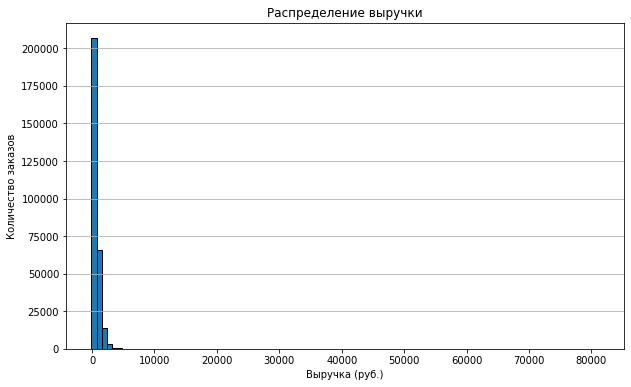

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['revenue_rub'], 
    bins=100,            
    edgecolor='black'     
)
plt.grid(axis='y')      
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество заказов')

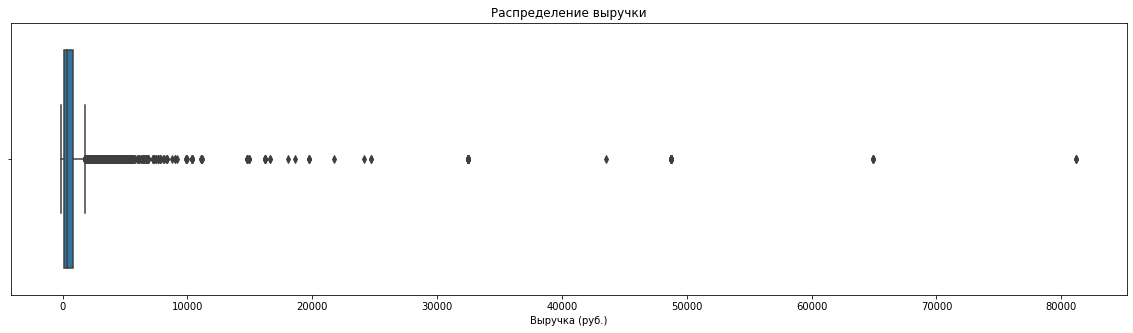

In [28]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=df, x='revenue_rub')

plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.show()

На лицо явные выбросы. Данные в основном расположены близко к началу отсчета.Тогда возьмем 99 проценталь по этому полю, а также отфильтруем отрицательную прибыль.

In [29]:
filtered_df = df[(df['revenue_rub'] > 0) & (df['revenue_rub'] <= df['revenue_rub'].quantile(0.99))]

In [30]:
filtered_df['revenue_rub'].describe()

count    281879.000000
mean        528.888184
std         511.717224
min           0.020000
25%         122.690002
50%         358.290009
75%         798.070007
max        2628.421631
Name: revenue_rub, dtype: float64

Text(0, 0.5, 'Количество заказов')

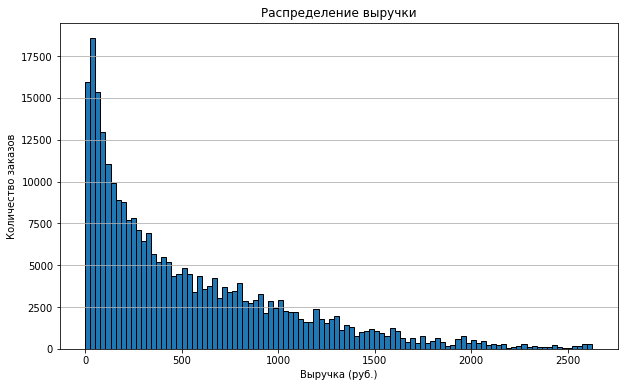

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(
    filtered_df['revenue_rub'], 
    bins=100,            
    edgecolor='black'     
)
plt.grid(axis='y')      
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество заказов')

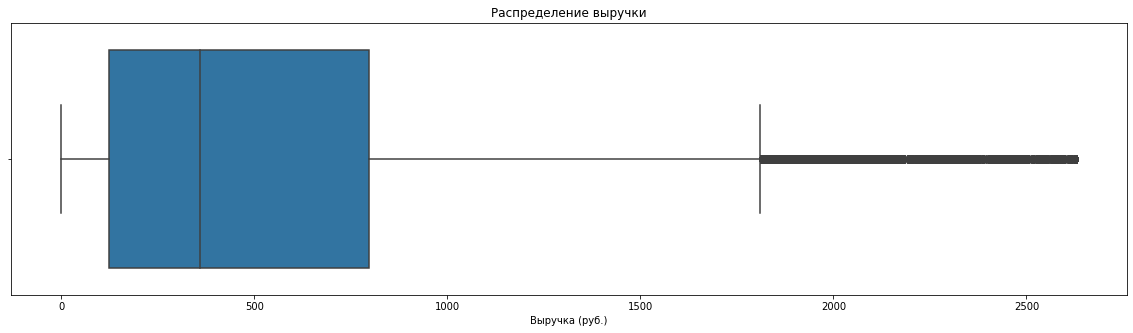

In [32]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=filtered_df, x='revenue_rub')

plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.show()

Теперь Графики смотрятся более наглядно.  Второй параметр будем проверять сначала на исходных, потом на отфильтрованных данных

In [33]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Text(0, 0.5, 'Количество заказов')

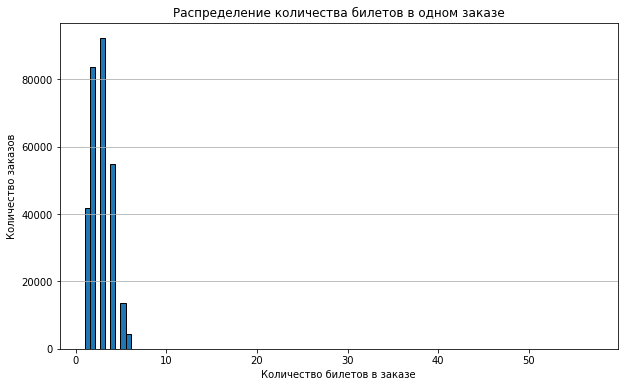

In [34]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['tickets_count'], 
    bins=100,   
    edgecolor='black'     
)
plt.grid(axis='y')    
plt.title('Распределение количества билетов в одном заказе')
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Количество заказов')

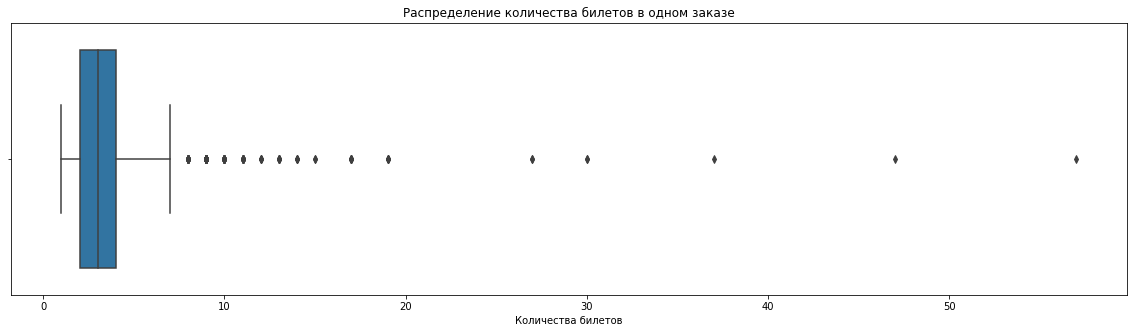

In [35]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=df, x='tickets_count')

plt.title('Распределение количества билетов в одном заказе')
plt.xlabel('Количества билетов')
plt.show()

Теперь посмотрим как этот столбец представлен в отсортированном датасете.

In [36]:
filtered_df['tickets_count'].describe()

count    281879.000000
mean          2.744117
std           1.157190
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

Text(0, 0.5, 'Количество заказов')

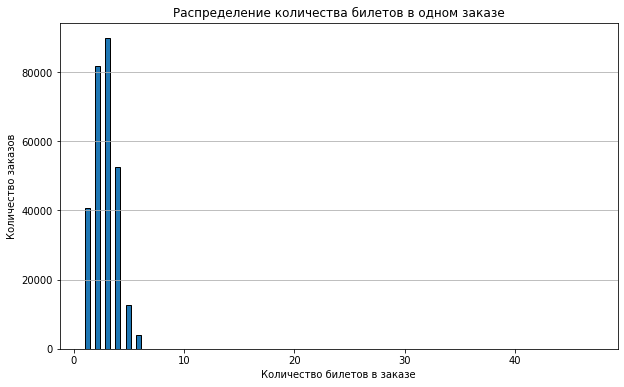

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(
    filtered_df['tickets_count'], 
    bins=100,   
    edgecolor='black'     
)
plt.grid(axis='y')    
plt.title('Распределение количества билетов в одном заказе')
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Количество заказов')

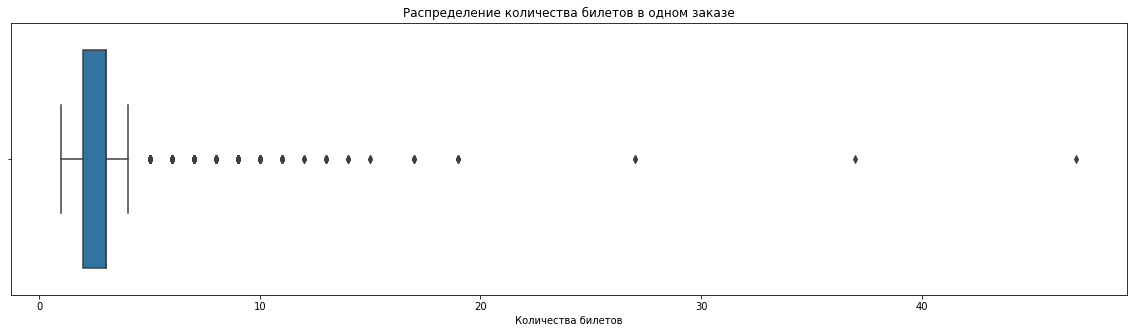

In [38]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=filtered_df, x='tickets_count')

plt.title('Распределение количества билетов в одном заказе')
plt.xlabel('Количества билетов')
plt.show()

В данном столбце можно отметить большее количество выбросов. Это может быть связано с попупкой билетов на большие группы (экскурсии или, например, класс/группа обучающихся).

Посмотрим из чего состоит датасет filtered_df

In [39]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281879 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                281879 non-null  object        
 1   device_type_canonical  281879 non-null  object        
 2   order_id               281879 non-null  int32         
 3   order_dt               281879 non-null  datetime64[ns]
 4   order_ts               281879 non-null  datetime64[ns]
 5   currency_code          281879 non-null  object        
 6   revenue                281879 non-null  float32       
 7   tickets_count          281879 non-null  int8          
 8   days_since_prev        260497 non-null  float64       
 9   event_id               281879 non-null  int32         
 10  event_name             281879 non-null  object        
 11  event_type_main        281879 non-null  object        
 12  service_name           281879 non-null  obje

In [40]:
del_str = df.shape[0] - filtered_df.shape[0]
del_str_proc = round(del_str / df.shape[0] * 100, 3)
f'Было удалено {del_str} строк, что составило {del_str_proc}% от исходного датасета'

'Было удалено 8732 строк, что составило 3.005% от исходного датасета'

#### **Промежуточный вывод после предобработки данных**

- Преобразовали типы данных в некоторых столбцах order_id, order_dt, order_ts, revenue, tickets_count, event_id, revenue_rub;
- Изучили значения в ключевых столбцах. Критических ошибок не обнаружено;
- Проверили, какие категории указаны в столбцах с номинальными данными. В столбце event_type_main есть категория "другое". Скорее всего так отмечали события, у которых не было данных или совсем странные категории. В остальных столбцах такого не замечено;
- Проверьте распределение численных данных и наличие в них выбросов в столбцах revenue_rub и tickets_count. Для этого использовали статистические показатели, гистограммы распределения значений или диаграммы размаха.
- Были обнаружегнв выбросы в поле revenue_rub. Отфильтровали значения по 99 перцентилю справа, и "> 0" слева.
- Было удалено 8732 строк, что составило 3.005% от исходного датасета

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [41]:
filtered_df = filtered_df.sort_values(by = 'order_ts')


In [42]:
user_profile = filtered_df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_partner=('service_name', 'first'),
    first_genre=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean') 
).reset_index()

In [43]:
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

Создали "карточку" пользователя.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [44]:
count_users = len(user_profile['user_id'])
avg_tot = round(user_profile['avg_revenue_rub'].mean(),2)
mor2 = round(user_profile['is_two'].sum() / count_users,4)
mor5 = round(user_profile['is_five'].sum() / count_users, 4)

In [45]:
f'''общее число пользователей в выборке - {count_users};
средняя выручка с одного заказа - {avg_tot};
доля пользователей, совершивших 2 и более заказа - {mor2};
доля пользователей, совершивших 5 и более заказов - {mor5}'''

'общее число пользователей в выборке - 21700;\nсредняя выручка с одного заказа - 551.8800048828125;\nдоля пользователей, совершивших 2 и более заказа - 0.6167;\nдоля пользователей, совершивших 5 и более заказов - 0.2887'

**Вопрос** это нормально, что мы считаем среднюю вырочку с одного заказа для всех по средней в.д.о.з. для каждого пользователя?

In [46]:
filtered_df['revenue_rub'].mean()

528.8882

In [47]:
sum(filtered_df['revenue_rub']) / len(filtered_df['order_id'].unique())

528.8883099064382

**Вопрос upd** если считать просто среднюю по выручке в исходном(отфильтрованном) датасете, то получается другой результат.

In [48]:
#чтобы не строить графики каждый раз для разных столбцов, сохдадим функцию
def analyze(df, col_name, title):
    '''
    Выводит describe(), строит гистограмму и боксплот для выбранного столбца
    '''
    # Описание столбца
    print(f'Статистические показатели для {title}')
    print(df[col_name].describe())
    print()
    
    #Гистограмма и боксплот
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(df[col_name], kde=True, ax=axes[0], color='#5dade2', bins=30)
    axes[0].set_title(f"Распределение: {title}", fontsize=11, fontweight='bold')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel("Количество пользователей")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    sns.boxplot(x=df[col_name], ax=axes[1], color='#f1948a')
    axes[1].set_title(f"Боксплот: {title}", fontsize=11, fontweight='bold')
    axes[1].set_xlabel(title)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # Отображаем графики
    plt.tight_layout()
    plt.show()
    
    

Статистические показатели для Общее число заказов
count    21700.000000
mean        12.989816
std        119.766778
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9987.000000
Name: total_orders, dtype: float64



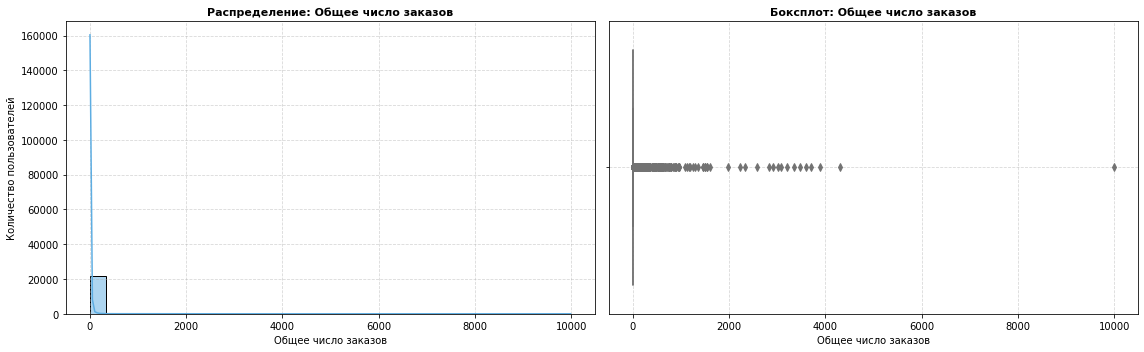

In [49]:
analyze(user_profile, 'total_orders', 'Общее число заказов')

In [50]:
user_profile[user_profile['total_orders'] == 9987]

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five
978,0beb8fc0c0a9ce1,2024-06-01,2024-10-31,mobile,Североярская область,Билеты в руки,концерты,9987,514.969055,2.870832,0.01452,True,True


 Пользователь `0beb8fc0c0a9ce1` сделал почти 10000 заказов! Он, конечно, молодец, но из анализа мы его исключим.

Статистические показатели для Среднее число билетов в заказе
count    21700.000000
mean         2.746006
std          0.914290
min          1.000000
25%          2.000000
50%          2.750000
75%          3.090909
max         11.000000
Name: avg_tickets_count, dtype: float64



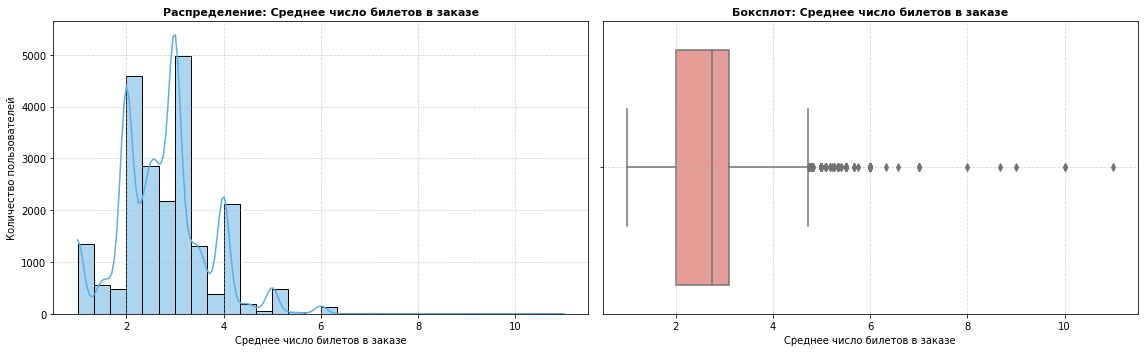

In [51]:
analyze(user_profile, 'avg_tickets_count', 'Среднее число билетов в заказе')

В данном столбце данные распределены более равномерно, но все равно встречаются высокие значения.

Статистические показатели для Среднее количество дней между покупками
count    13457.000000
mean        15.900942
std         22.341735
min          0.000000
25%          1.000000
50%          8.000000
75%         20.500000
max        148.000000
Name: avg_days_between, dtype: float64



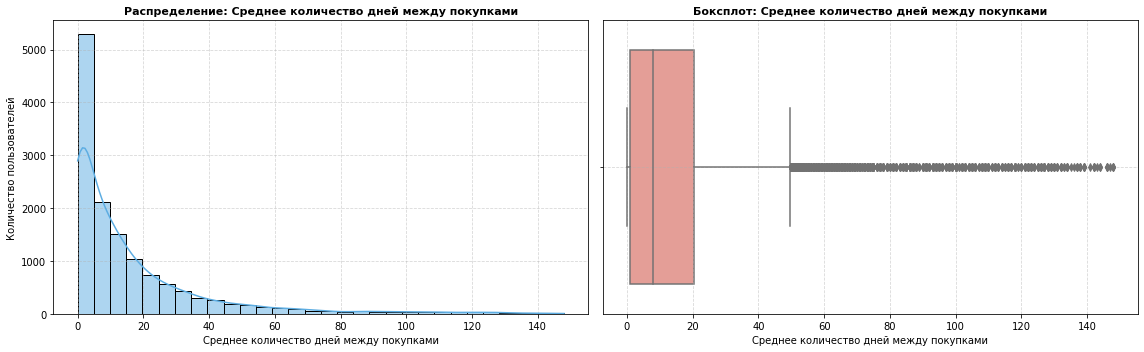

In [52]:
analyze(user_profile, 'avg_days_between', 'Среднее количество дней между покупками')

Тут, в связи со спецификой столбца, можно увидеть, что те пользователи, которые совершают повторные заказы, чаще делают это до 20 дней после предыдущего.

Для более качественного анализа лучше отфильтровать по 99 проценталю столбец total_orders.

In [53]:
filtered_up = user_profile[(user_profile['total_orders'] <= user_profile['total_orders'].quantile(0.99))].copy()

Статистические показатели для Общее число заказов
count    21483.000000
mean         6.404506
std         13.982574
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        150.000000
Name: total_orders, dtype: float64



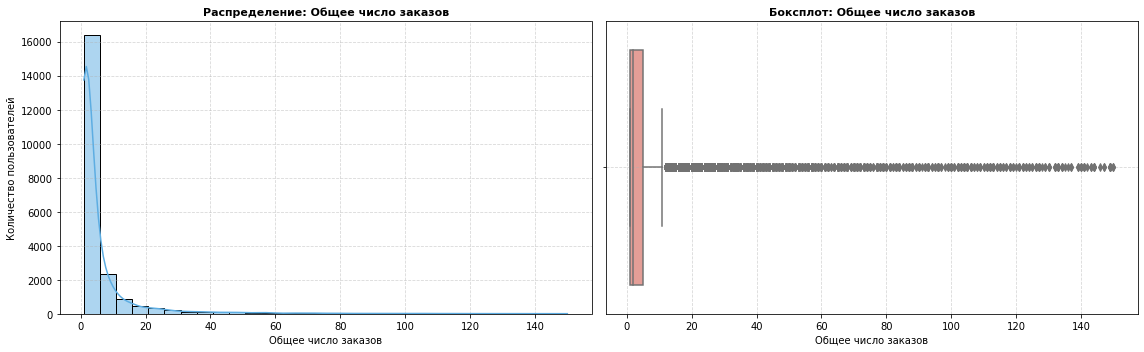

In [54]:
analyze(filtered_up, 'total_orders', 'Общее число заказов')

Стало нагляднее видно, что пользователи в основном делают не так много повторных заказов.

In [55]:
del_str = user_profile.shape[0] - filtered_up.shape[0]
del_str_proc = round(del_str / user_profile.shape[0] * 100, 3)
f'Было удалено {del_str} строк, что составило {del_str_proc}% от исходного датасета'

'Было удалено 217 строк, что составило 1.0% от исходного датасета'

In [56]:
filtered_up.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21483 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21483 non-null  object        
 1   first_order_dt     21483 non-null  datetime64[ns]
 2   last_order_dt      21483 non-null  datetime64[ns]
 3   first_device       21483 non-null  object        
 4   first_region       21483 non-null  object        
 5   first_partner      21483 non-null  object        
 6   first_genre        21483 non-null  object        
 7   total_orders       21483 non-null  int64         
 8   avg_revenue_rub    21483 non-null  float32       
 9   avg_tickets_count  21483 non-null  float64       
 10  avg_days_between   13240 non-null  float64       
 11  is_two             21483 non-null  bool          
 12  is_five            21483 non-null  bool          
dtypes: bool(2), datetime64[ns](2), float32(1), float64(2), int64(

In [57]:
count_users = len(filtered_up['user_id'])
avg_tot = round(filtered_up['avg_revenue_rub'].mean(),2)
mor2 = round(filtered_up['is_two'].sum() / count_users,4)
mor5 = round(filtered_up['is_five'].sum() / count_users, 4)
f'''общее число пользователей в выборке - {count_users};
средняя выручка с одного заказа - {avg_tot};
доля пользователей, совершивших 2 и более заказа - {mor2};
доля пользователей, совершивших 5 и более заказов - {mor5}'''

'общее число пользователей в выборке - 21483;\nсредняя выручка с одного заказа - 552.1500244140625;\nдоля пользователей, совершивших 2 и более заказа - 0.6128;\nдоля пользователей, совершивших 5 и более заказов - 0.2815'

Используя данные о профилях пользователей, рассчитали (с учетом фильтрации):

- общее число пользователей в выборке - 21483;
- среднюю выручку с одного заказа - 552.15;* если расчитывать среднее по исходным данным, а не по средней для каждого клиента, то будет 528.89
- долю пользователей, совершивших 2 и более заказа - 0.6128;
- долю пользователей, совершивших 5 и более заказов - 0.2815.

Также изучили статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.
По итогам решили сделать фильтрацию по `total_orders` из-за безумного выброса на 9987 заказов. 


Было удалено 217 строк, что составило 1.0% от исходного датасета.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [58]:
def segment_1(df, col_name, title):
    '''
    группирует пользователей по выбранному столбцу, подсчитывает количество и долю пользователей
    '''
    print(f'Группировка данных по {title}')
    df_gr_seg = df.groupby(col_name).agg(count_val=('user_id', 'count'))
    df_gr_seg['part_of_total'] =  (df_gr_seg['count_val'] / df.shape[0] * 100).round(2)
    print(df_gr_seg.sort_values(by ='part_of_total', ascending = False))
    
    plt.figure(figsize=(10, max(3, len(df_gr_seg) * 0.5))) 
    
    sns.barplot(
        data=df_gr_seg.sort_values(by ='part_of_total', ascending = False).reset_index(), 
        x='part_of_total', 
        y=col_name, 
        palette='Blues_r')
    
    plt.title(f'Распределение пользователей по: {title}', fontsize=12, fontweight='bold')
    plt.xlabel('Доля пользователей (%)')
    plt.ylabel(title)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    

Группировка данных по типу их первого мероприятия
             count_val  part_of_total
first_genre                          
концерты          9607          44.72
другое            5223          24.31
театр             4259          19.82
стендап           1117           5.20
спорт              765           3.56
выставки           415           1.93
ёлки                97           0.45


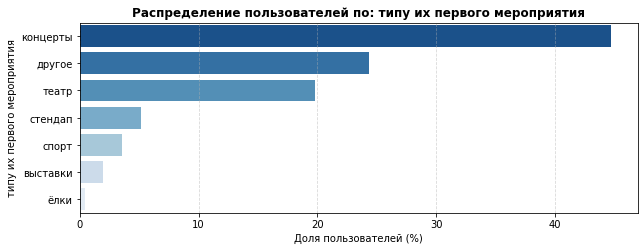

In [59]:
segment_1(filtered_up, 'first_genre', 'типу их первого мероприятия')

Группировка данных по устройству первого заказа
              count_val  part_of_total
first_device                          
mobile            17802          82.87
desktop            3681          17.13


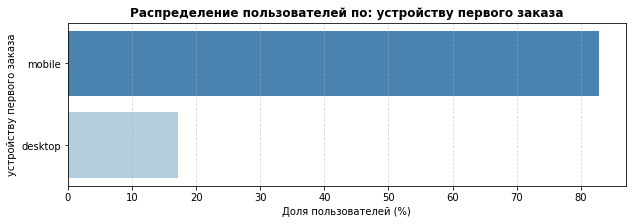

In [60]:
segment_1(filtered_up, 'first_device', 'устройству первого заказа')

Группировка данных по региону первого заказа
                          count_val  part_of_total
first_region                                      
Каменевский регион             6973          32.46
Североярская область           3783          17.61
Широковская область            1234           5.74
Озернинский край                678           3.16
Малиновоярский округ            527           2.45
...                             ...            ...
Лесноярский край                  3           0.01
Теплоозёрский округ               3           0.01
Верхозёрский край                 1           0.00
Сосноводолинская область          1           0.00
Яснопольский округ                1           0.00

[81 rows x 2 columns]


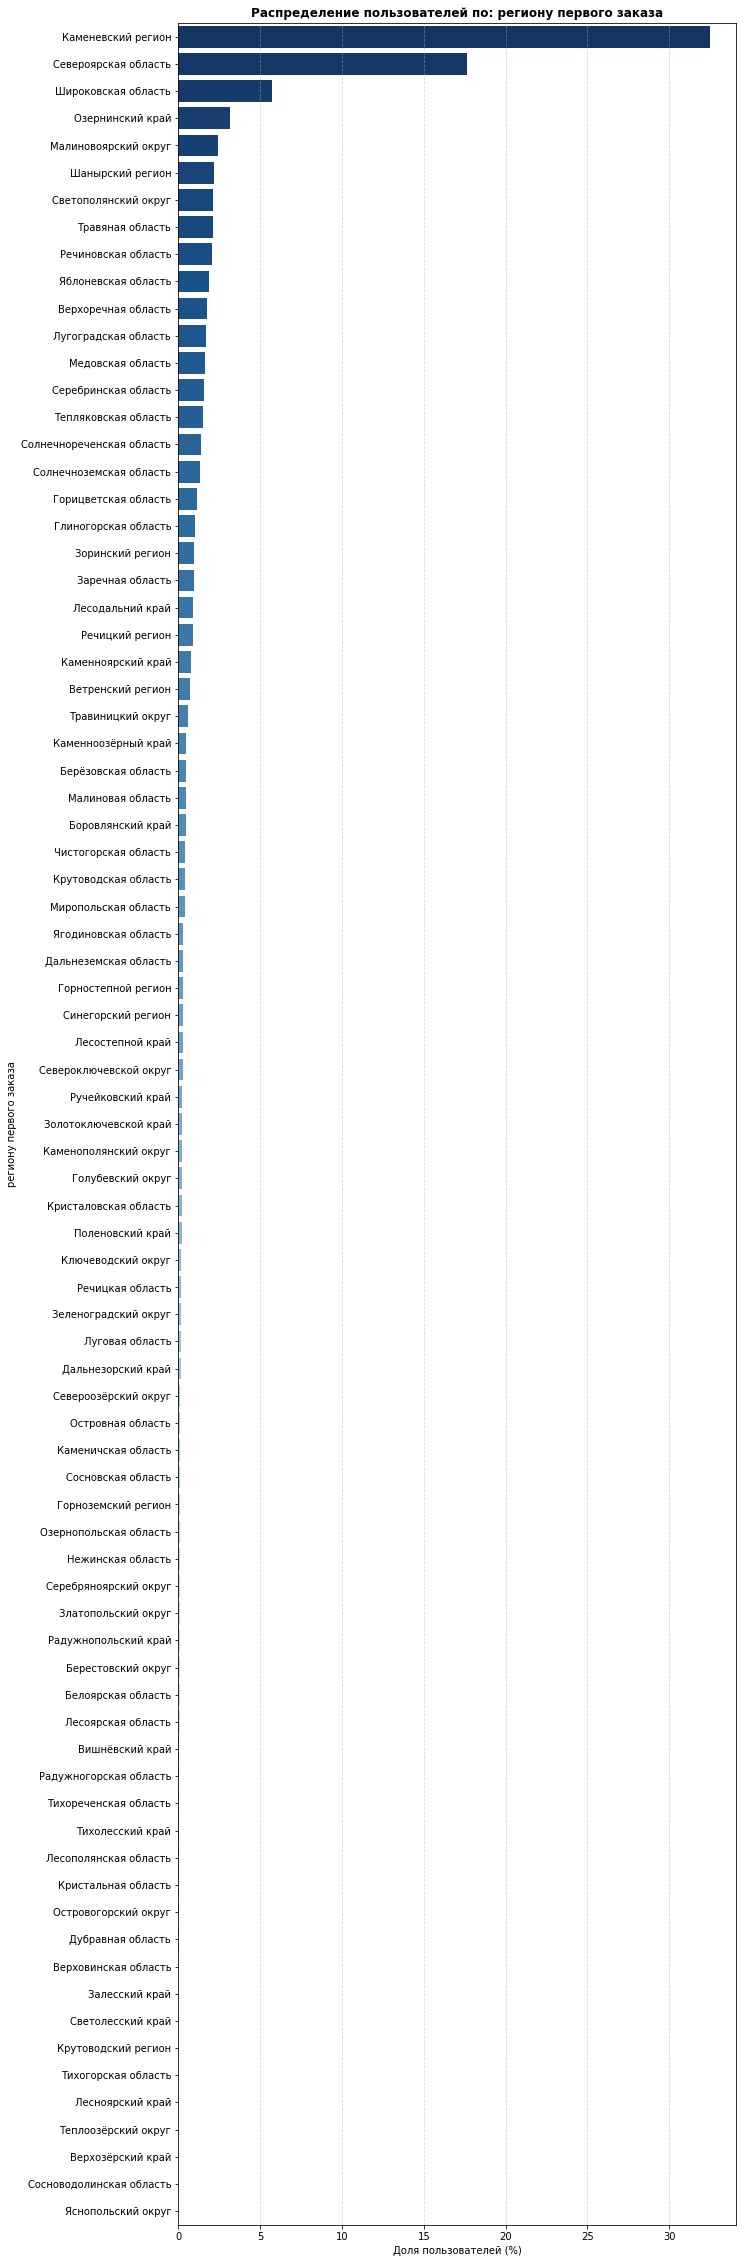

In [61]:
segment_1(filtered_up, 'first_region', 'региону первого заказа')

Группировка данных по билетному партнеру первого заказа
                        count_val  part_of_total
first_partner                                   
Билеты без проблем           4968          23.13
Мой билет                    2996          13.95
Лови билет!                  2801          13.04
Билеты в руки                2548          11.86
Облачко                      2196          10.22
Весь в билетах               1291           6.01
Лучшие билеты                1183           5.51
Прачечная                     586           2.73
Край билетов                  460           2.14
Дом культуры                  358           1.67
Яблоко                        320           1.49
Тебе билет!                   310           1.44
Городской дом культуры        218           1.01
Мир касс                      213           0.99
За билетом!                   204           0.95
Быстробилет                   165           0.77
Show_ticket                   157           0.73
Выступления.р

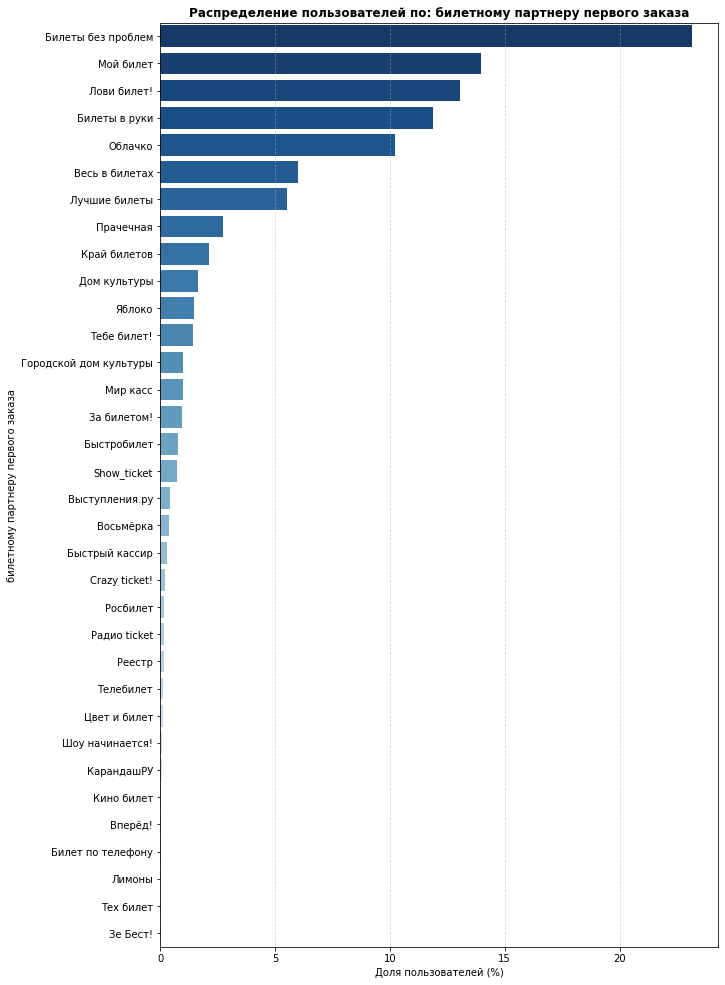

In [62]:
segment_1(filtered_up, 'first_partner', 'билетному партнеру первого заказа')

Данные распределены не равномерно. Есть отчетливые "точки входа" - концерты, мобильные устройсва, Каменевский регион и "Билеты без проблем".

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [63]:
def segment_2(df, col_name, title):
    '''
    группирует пользователей по выбранному столбцу, подсчитывает количество и долю пользователей. 
    2 версия выводит только топ-10 вариантов; 
    так как мы знаем, что есть колонка is_two, в которой булевы значения, то будем считать сумму по этому столбцу, 
    чтобы найти количество "вернувшихся" пользователей.
    '''
    print(f'Анализ возвращаемости по {title}')
    df_gr_seg = df.groupby(col_name).agg(count_val=('user_id', 'count'), returned_users=('is_two', 'sum'))
    df_gr_seg['returnation'] = (df_gr_seg['returned_users'] / df_gr_seg['count_val'] * 100).round(2)
    df_gr_seg_top = df_gr_seg.sort_values(by='returnation', ascending=False).head(10)
    print(df_gr_seg_top)
    

    
    plt.figure(figsize=(10, max(3, len(df_gr_seg_top) * 0.5)))
    
    sns.barplot(
        data=df_gr_seg_top.reset_index(), 
        x='returnation', 
        y=col_name, 
        palette='Greens_r' 
    )
   
    mean_retention = df['is_two'].mean() * 100
    plt.axvline(
        mean_retention, 
        color='red', 
        linestyle='--', 
        alpha=0.7, 
        label=f'Среднее по выборке ({mean_retention:.2f}%)')



    plt.title(f'Доля вернувшихся по: {title}', fontsize=12, fontweight='bold')
    plt.xlabel('Доля совершивших 2+ заказа (%)')
    plt.ylabel(title)
    plt.legend(loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

Анализ возвращаемости по типу их первого мероприятия
             count_val  returned_users  returnation
first_genre                                        
выставки           415             267        64.34
театр             4259            2704        63.49
концерты          9607            5935        61.78
стендап           1117             680        60.88
другое            5223            3104        59.43
ёлки                97              55        56.70
спорт              765             420        54.90


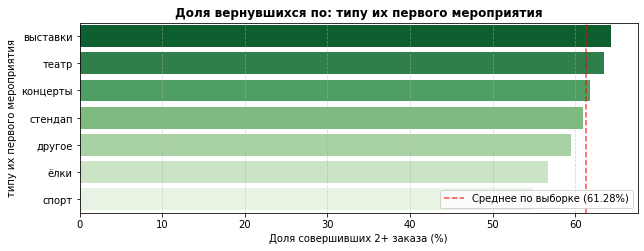

In [64]:
segment_2(filtered_up, 'first_genre', 'типу их первого мероприятия')

Анализ возвращаемости по устройству первого заказа
              count_val  returned_users  returnation
first_device                                        
desktop            3681            2340        63.57
mobile            17802           10825        60.81


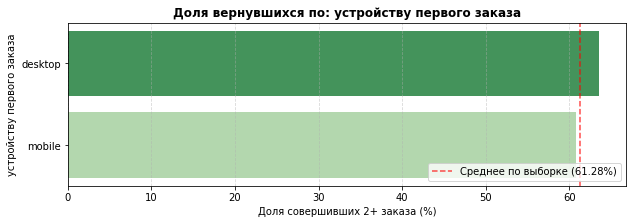

In [65]:
segment_2(filtered_up, 'first_device', 'устройству первого заказа')

Анализ возвращаемости по региону первого заказа
                        count_val  returned_users  returnation
first_region                                                  
Верхозёрский край               1               1       100.00
Озернопольская область         29              26        89.66
Радужнопольский край           24              19        79.17
Лесостепной край               61              43        70.49
Тихолесский край               10               7        70.00
Шанырский регион              465             323        69.46
Горноземский регион            29              20        68.97
Горицветская область          249             167        67.07
Ягодиновская область           63              42        66.67
Верховинская область            3               2        66.67


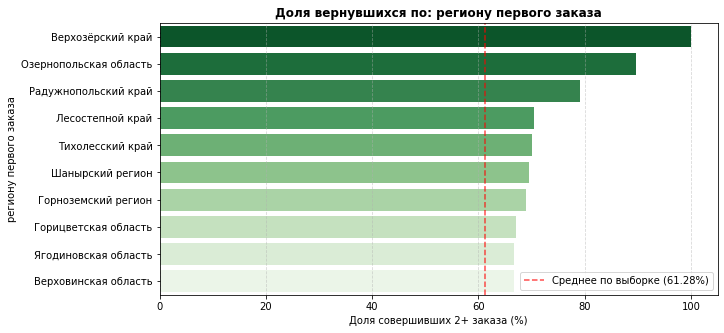

In [66]:
segment_2(filtered_up, 'first_region', 'региону первого заказа')

Анализ возвращаемости по билетному партнеру первого заказа
                   count_val  returned_users  returnation
first_partner                                            
Зе Бест!                   1               1       100.00
Быстрый кассир            61              52        85.25
Билет по телефону          6               5        83.33
Реестр                    33              27        81.82
Crazy ticket!             46              32        69.57
Восьмёрка                 86              59        68.60
Край билетов             460             301        65.43
Цвет и билет              23              15        65.22
Росбилет                  40              26        65.00
Show_ticket              157             102        64.97


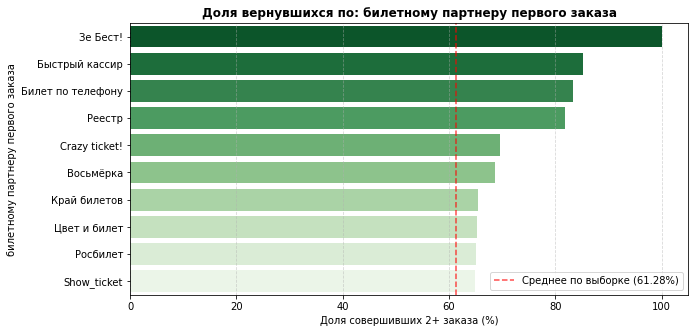

In [67]:
segment_2(filtered_up, 'first_partner', 'билетному партнеру первого заказа')

Точки входа изменились. Следующие сегменты показали себя лучше, чем средняя по выборке: (выставки, театр, концерты), десктопные пользователи, все топ-10 регионов и партнеров первого заказа.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1** верна лишь отчасти. Тип мероприятия влияет на вероятность возврата, но не так, как описано в ней. Больше всего возвращаются пользователи, совершившие первый заказ на выставки.

Вероятность верности **Гипотезы 2** в принципе очень мала из-за механизма расчета **доли** повторных заказов. Это отчетливо видно на примере Верхозёрского края. Там был активен лишь 1 пользователь, но из-за того, что он совершил повторный заказ, там 100% вероятность возврата. Соответственно, в регионе, где много заказов, но не так часто совершают повторные, **доля** возврата будет не такая большая. Но использовать такие данные для расчета будет не совсем верно.
Тут смотря чего хочет от нас заказчик. Если надо определить долю (как в задании), чтобы сделать красивый отчет, то оставляем так. А если нужно реально поднять выручку, то в данной ситуации, по-моему мнению, надо смотреть на абсолютные показатели

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


<AxesSubplot:xlabel='avg_revenue_rub', ylabel='Count'>

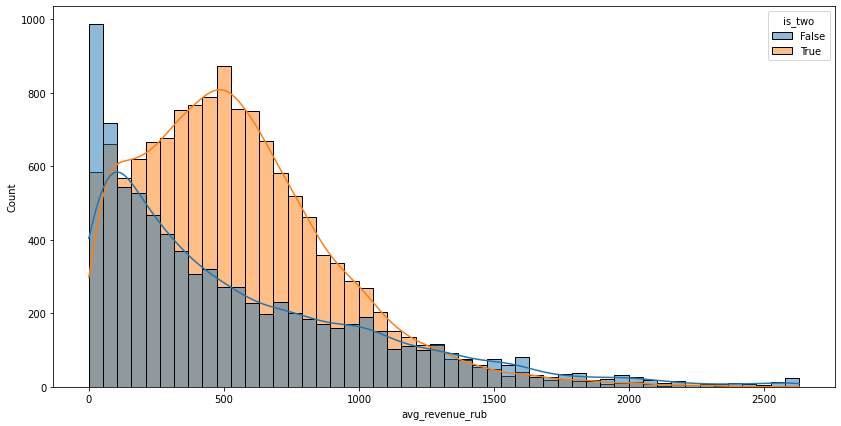

In [68]:
plt.figure(figsize=(14, 7))
sns.histplot(data=filtered_up, x='avg_revenue_rub', bins=50, kde=True, hue = 'is_two')

Можно заметить, что группы отличаются друг от друга. Пользователи, которые не совершили повторные заказы (синий цвет), в основном сконцетрированы в начале графика, то есть более чаще приносят малую вырочку, в то время как "вернувшиеся" пользователи приносят вырочку чаще в районе 500.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [69]:
df_more_two = filtered_up[filtered_up['is_two'] == True]

<AxesSubplot:xlabel='avg_revenue_rub', ylabel='Count'>

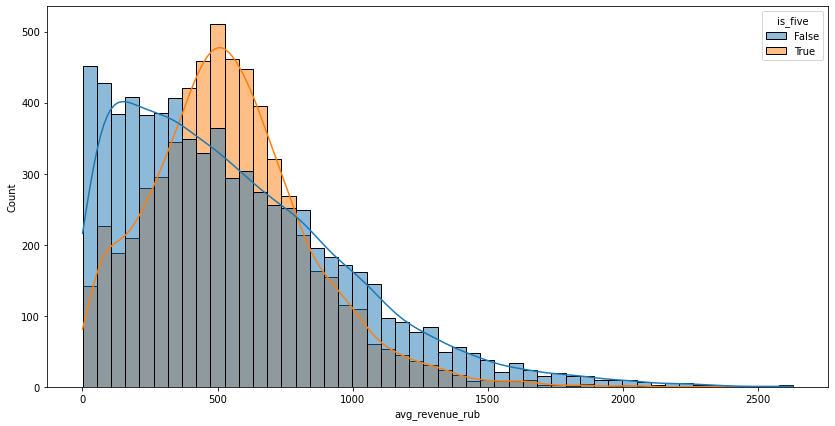

In [70]:
plt.figure(figsize=(14, 7))
sns.histplot(data=df_more_two, x='avg_revenue_rub', bins=50, kde=True, hue = 'is_five')

В данной сортировке картина повторяется - в районе 500 попадаются самые "верные" пользователи. А чем ближе к началу графика, тем больше пользователей, которые вернулись меньшее количество раз.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [71]:
filtered_up['cut_avg_tickets_count'] = pd.cut(filtered_up['avg_tickets_count'], bins=[0, 2, 3, 5, 1000], labels=["от 1 до 2", "от 2 до 3", "от 3 до 5", "от 5 и более"])

In [72]:
df_group_avg_tick = filtered_up.groupby('cut_avg_tickets_count').agg(total_users = ('user_id','count'), returned_users=('is_two', 'sum'))
df_group_avg_tick['returnation'] = (df_group_avg_tick['returned_users'] / df_group_avg_tick['total_users'] * 100).round(2)
df_group_avg_tick

,total_users,returned_users,returnation
cut_avg_tickets_count,,,
от 1 до 2,6109,2445,40.02
от 2 до 3,9833,7298,74.22
от 3 до 5,5347,3359,62.82
от 5 и более,194,63,32.47


In [73]:
# Для более удобной визуализации
styled_table = df_group_avg_tick.style\
    .format({
        'total_users': '{:,}',
        'returned_users': '{:,}', 
        'returnation': '{:.2f}%'   
    })\
    .background_gradient(subset=['total_users'], cmap='Blues')\
    .background_gradient(subset=['returnation'], cmap='Oranges')

styled_table

,total_users,returned_users,returnation
cut_avg_tickets_count,,,
от 1 до 2,"6,109","2,445",40.02%
от 2 до 3,"9,833","7,298",74.22%
от 3 до 5,"5,347","3,359",62.82%
от 5 и более,194,63,32.47%


Проведенный анализ позволил увидеть:
- данные распределены не очень равномерно (особенно учитывая сегмент "от 5 и более");
- в сегменте "от 2 до 3" наблюдается самый высокий процент "возврата" и больше всего покупок в принципе;
- в то время как в сегментах "от 5 и более" и "от 1 до 2" процент возврата не такой большой.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [74]:
filtered_up['day_w'] = filtered_up['first_order_dt'].dt.strftime('%A')
df_analyze_day = filtered_up.groupby('day_w').agg(total_users = ('user_id','count'), returned_users=('is_two', 'sum'))
df_analyze_day['returnation'] = (df_analyze_day['returned_users'] / df_analyze_day['total_users'] * 100).round(2)
df_analyze_day = df_analyze_day.sort_values(by ='returnation', ascending = False)
styled_table = df_analyze_day.style\
    .format({
        'total_users': '{:,}',
        'returned': '{:.2f}%'   
    })\
    .background_gradient(subset=['total_users'], cmap='Blues')\
    .background_gradient(subset=['returnation'], cmap='Oranges')

styled_table

,total_users,returned_users,returnation
day_w,,,
Saturday,"3,292",2067,62.790000
Monday,"2,901",1817,62.630000
Wednesday,"3,048",1895,62.170000
Tuesday,"3,157",1949,61.740000
Sunday,"2,757",1659,60.170000
Friday,"3,230",1935,59.910000
Thursday,"3,098",1843,59.490000


День недели практически не влияет на "возврат" пользователя. Наблюдается незначительное повышение количества повторных покупок у пользователей, совершивших первый заказ в Субботу.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [75]:
# Воспользуемся вспомогательным датасетом, который мы делали ранее
df_days_between = df_more_two.groupby('is_five')['avg_days_between'].mean()
df_days_between

is_five
False    21.219315
True      9.890956
Name: avg_days_between, dtype: float64

Среднее время между заказами у пользователей с 5+ покупками в 2 раза меньше, чем с 2-4!

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [76]:
df_corr_all = filtered_up[[
    'first_genre', 
    'first_device', 
    'first_region', 
    'first_partner',
    'total_orders', 
    'avg_revenue_rub', 
    'avg_tickets_count', 
    'avg_days_between'
]].copy()
phik_matrix = df_corr_all.phik_matrix()
orders_corr = phik_matrix['total_orders'].drop('total_orders').sort_values(ascending=False)
orders_corr_df = orders_corr.to_frame(name='Коэффициент Phik').round(3)

orders_corr_df

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']


,Коэффициент Phik
avg_days_between,0.295
avg_tickets_count,0.231
avg_revenue_rub,0.226
first_region,0.125
first_partner,0.031
first_genre,0.029
first_device,0.016


<AxesSubplot:>

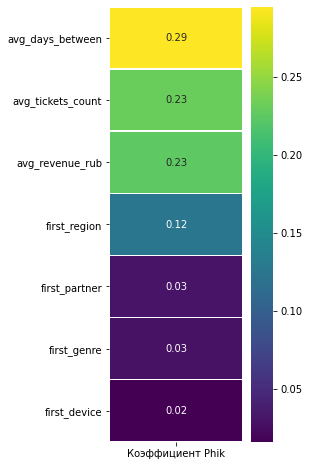

In [77]:
# Создаём визуализацию
plt.figure(figsize=(3, 8))

sns.heatmap(data=orders_corr_df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')


Сильной корелляции не замечено. Попробуем разбить  на группы.

In [78]:
df_corr_all['cut_total_orders'] = pd.cut(df_corr_all['total_orders'], bins=[1, 2, 5, 1000], labels=["1 заказ", "от 2 до 4", "от 5 и более"])

In [79]:
phik_matrix_2 = df_corr_all.phik_matrix()
orders_corr_2 = phik_matrix_2['cut_total_orders'].drop(['cut_total_orders', 'total_orders']).sort_values(ascending=False)
orders_corr_df_2 = orders_corr_2.to_frame(name='Коэффициент Phik').round(3)

orders_corr_df_2

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']


,Коэффициент Phik
avg_days_between,0.492
avg_tickets_count,0.301
avg_revenue_rub,0.273
first_region,0.119
first_partner,0.078
first_genre,0.023
first_device,0.009


<AxesSubplot:>

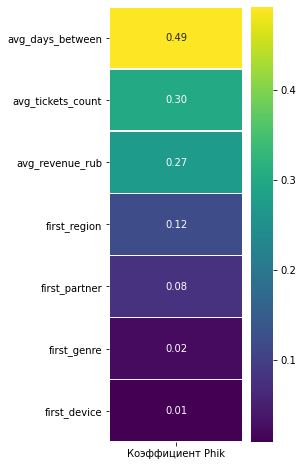

In [80]:
# Создаём визуализацию
plt.figure(figsize=(3, 8))

sns.heatmap(data=orders_corr_df_2, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

Теперь видна заметная корриляция с колонкой **avg_days_between**

# Вывод

1) - После выгрузки с помощью SQL мы получили датасет, который состоял из 15 столбцов и 290611 строк.
- Пропуски встречаются только в столбце days_since_prev, что обусловлено особенностью заполнения столбца (была всего одна покупка). 
- Типы данных соответствуют назначению столбцов, только в days_since_prev из-за пропусков целочисленные значения стали типа float. 
- Из-за того, что использованы разные валюты, пришлось создавать отдельный столбец с выручкой в рублях.

2) - Преобразовали типы данных в некоторых столбцах order_id, order_dt, order_ts, revenue, tickets_count, event_id, revenue_rub;
- Изучили значения в ключевых столбцах. Критических ошибок не обнаружено;
- Проверили, какие категории указаны в столбцах с номинальными данными. В столбце event_type_main есть категория "другое". Скорее всего так отмечали события, у которых не было данных или совсем странные категории. В остальных столбцах такого не замечено;
- Проверьте распределение численных данных и наличие в них выбросов в столбцах revenue_rub и tickets_count. Для этого использовали статистические показатели, гистограммы распределения значений или диаграммы размаха.
- Были обнаружегнв выбросы в поле revenue_rub. Отфильтровали значения по 99 перцентилю справа, и "> 0" слева.
- Было удалено 8732 строк, что составило 3.005% от исходного датасета

3) Был создан профиль пользователя :
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле event_type_main);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

4) Используя данные о профилях пользователей, рассчитали (с учетом фильтрации):
- общее число пользователей в выборке - 21483;
- среднюю выручку с одного заказа - 552.15;* если расчитывать среднее по исходным данным, а не по средней для каждого клиента, то будет 528.89
- долю пользователей, совершивших 2 и более заказа - 0.6128;
- долю пользователей, совершивших 5 и более заказов - 0.2815.
 Также изучили статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками. По итогам решили сделать фильтрацию по total_orders из-за безумного выброса на 9987 заказов.
- Было удалено 217 строк, что составило 1.0% от исходного датасета.
- Данные распределены не равномерно. Есть отчетливые "точки входа" - концерты, мобильные устройсва, Каменевский регион и "Билеты без проблем".
- Если рассматривать на обычных (2-4 покупки) и "суперлояльных" (5 и более покупок) Точки входа изменились. Следующие сегменты показали себя лучше, чем средняя по выборке: (выставки, театр, концерты), десктопные пользователи, все топ-10 регионов и партнеров первого заказа.

5) - Тип мероприятия влияет на вероятность возврата. Больше всего возвращаются пользователи, совершившие первый заказ на выставки.
- Было сложно оценить вероятность верности зависимости "возвратов" от регионов  из-за механизма расчета доли повторных заказов. Это отчетливо видно на примере Верхозёрского края. Там был активен лишь 1 пользователь, но из-за того, что он совершил повторный заказ, там 100% вероятность возврата. Соответственно, в регионе, где много заказов, но не так часто совершают повторные, доля возврата будет не такая большая. Но использовать такие данные для расчета будет не совсем верно. Тут смотря чего хочет от нас заказчик. Если надо определить долю (как в задании), чтобы сделать красивый отчет, то оставляем так. А если нужно реально поднять выручку, то в данной ситуации, по-моему мнению, надо смотреть на абсолютные показатели

6) Сравнили группы пользователей:
 - Пользователи, которые не совершили повторные заказы , в основном сконцетрированы в начале графика, то есть более чаще приносят малую вырочку, в то время как "вернувшиеся" пользователи приносят вырочку чаще в районе 500.

- Если рассматривать обычных (2-4 покупки) и "суперлояльных" (5 и более покупок), картина повторяется - в районе 500 попадаются самые "верные" пользователи. А чем ближе к началу графика, тем больше пользователей, которые вернулись меньшее количество раз.

7) Проведенный анализ по количеству билетов в заказе позволил увидеть:

- данные распределены не очень равномерно (особенно учитывая сегмент "от 5 и более");
- в сегменте "от 2 до 3" наблюдается самый высокий процент "возврата" и больше всего покупок в принципе;
- в то время как в сегментах "от 5 и более" и "от 1 до 2" процент возврата не такой большой.

8) День недели практически не влияет на "возврат" пользователя. Наблюдается незначительное повышение количества повторных покупок у пользователей, совершивших первый заказ в Субботу.

9) Среднее время между заказами у пользователей с 5+ покупками в 2 раза меньше, чем с 2-4!

10) Рассчитанный коэффициент корреляции phi_k для немного преобразованных даных (заказы объеденены в группы) показал корелляцию со столбцом avg_days_between.

После проведенного анализа можно сделать вывод:
пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно это пользователи, которые:
- купили в 1 раз "от 2 до 3" билетов
- сделали 1 заказ в Субботу (не сильно влияет)
- средняя выручка от их покупки составила ~500 рублей
- перывый заказ на выставки, театр, концерт
- с десктопного приложения возвращаются немного чаще, но количественно больше с мобильной, стоит проработать эту часть.
- стоит "заставить" купить повторный билет как можно раньше, это позволит "затянуть" пользователя (видна явная корелляция)

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**